In [ ]:
# ====================================================
# 0) INSTALLS (Colab only - run once)
# ====================================================
# (No external packages needed beyond standard Colab stack)
# You can leave this cell empty or use it for Drive mounting if needed, e.g.:
# from google.colab import drive
# drive.mount('/content/drive')


In [1]:
# ====================================================
# 1) CONFIGURATION
#    All variables are defined here
# ====================================================

import types

CFG = types.SimpleNamespace()

# ---- Data paths / format ----
# Folder that contains your CSV files (each with 161 columns)
# Change this to your actual folder path (e.g. "/content/drive/MyDrive/patch_data")
CFG.data_dir        = "/content"   # <-- EDIT THIS
CFG.csv_pattern     = "*.csv"           # all CSVs in data_dir will be loaded and concatenated

# Data layout
CFG.grid_h          = 10
CFG.grid_w          = 10
CFG.in_dim          = CFG.grid_h * CFG.grid_w  # 100 geometry bits
CFG.out_dim         = 61                       # real S11 values (cols 101..161)

# Train/val split
CFG.val_ratio       = 0.2
CFG.shuffle_data    = True
CFG.random_seed     = 42

# Training hyperparameters
CFG.batch_size      = 32
CFG.num_epochs      = 20
CFG.learning_rate   = 1e-3
CFG.weight_decay    = 1e-4

# Model hyperparameters
CFG.d_model         = 64        # latent dimension
CFG.cnn_channels    = [32, 64, 128]  # CNN encoder channels
CFG.num_decoder_layers = 1
CFG.n_heads         = 8          # (not used in the simplified FEDformer block here but kept for config)
CFG.dropout         = 0.1
CFG.fourier_modes   = 16         # how many low-frequency modes to keep

# Augmentation config (on INPUT geometry only)
CFG.use_augmentation = False      # turn on/off all augmentation
CFG.bit_flip_prob    = 0.05      # probability of flipping each bit (0 <-> 1)
CFG.noise_std        = 0.10      # Gaussian noise std added to input, then clipped to [0,1]

# Device
import torch
CFG.device          = "cuda" if torch.cuda.is_available() else "cpu"

CFG


namespace(data_dir='/content',
          csv_pattern='*.csv',
          grid_h=10,
          grid_w=10,
          in_dim=100,
          out_dim=61,
          val_ratio=0.2,
          shuffle_data=True,
          random_seed=42,
          batch_size=32,
          num_epochs=20,
          learning_rate=0.001,
          weight_decay=0.0001,
          d_model=64,
          cnn_channels=[32, 64, 128],
          num_decoder_layers=1,
          n_heads=8,
          dropout=0.1,
          fourier_modes=16,
          use_augmentation=False,
          bit_flip_prob=0.05,
          noise_std=0.1,
          device='cpu')

In [2]:
# ====================================================
# 2) IMPORTS & SEEDING
# ====================================================

import os, glob, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

# Reproducibility
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CFG.random_seed)

print("Using device:", CFG.device)


Using device: cpu


In [4]:
# ====================================================
# 3) LOAD & INSPECT DATA
#    - Reads all CSVs in CFG.data_dir matching CFG.csv_pattern
#    - Concatenates into one DataFrame
#    - Splits into X (geometry) and y (S11 real values)
# ====================================================

# Collect all CSV file paths
csv_files = sorted(glob.glob(os.path.join(CFG.data_dir, CFG.csv_pattern)))
print("Found CSV files:", csv_files)

if len(csv_files) == 0:
    raise FileNotFoundError(
        f"No CSV files found in {CFG.data_dir}. "
        "Please upload your data and update CFG.data_dir."
    )

# Read and concatenate
df_list = []
for f in csv_files:
    df_part = pd.read_csv(f, header=None)  # no header assumed
    df_list.append(df_part)

df = pd.concat(df_list, axis=0, ignore_index=True)
print(f"Combined data shape: {df.shape}")

# Quick sanity check on column count
if df.shape[1] != (CFG.in_dim + CFG.out_dim):
    raise ValueError(
        f"Expected {CFG.in_dim + CFG.out_dim} columns (100 geom + 61 S11), "
        f"but got {df.shape[1]}"
    )

print("\nFirst 5 rows of raw data:")
display(df.head())

# Split into input (geometry) and output (S11 real)
geom_df = df.iloc[:, :CFG.in_dim]
s11_df  = df.iloc[:, CFG.in_dim:CFG.in_dim + CFG.out_dim]

print("\nGeometry subset shape:", geom_df.shape)
print("S11 real subset shape:", s11_df.shape)

print("\nGeometry (first row, first 20 bits):")
print(geom_df.iloc[0, :20].values)

print("\nS11 real values (first row):")
print(s11_df.iloc[0].values)

# Convert to numpy arrays
X_all = geom_df.values.astype(np.float32)
y_all = s11_df.values.astype(np.float32)

print("\nNumpy shapes -> X_all:", X_all.shape, ", y_all:", y_all.shape)


Found CSV files: ['/content/No2767_Complete.csv']
Combined data shape: (5999, 161)

First 5 rows of raw data:


,0,1,2,3,4,5,6,7,8,9,...,151,152,153,154,155,156,157,158,159,160
0,1,1,0,0,0,1,0,1,0,0,...,-4.317797,-8.326290,-3.075395,-2.360956,-2.272893,-2.275419,-2.937963,-3.183707,-3.534243,-4.306054
1,0,1,1,1,1,0,0,0,1,0,...,-0.459345,-1.000122,-6.950734,-1.556966,-0.520855,-0.492500,-1.112343,-1.148749,-1.509570,-4.474445
2,0,0,0,0,0,1,0,0,1,1,...,-3.670384,-3.085866,-2.701348,-1.918337,-2.825056,-5.309183,-6.113160,-4.193374,-6.655983,-3.875439
3,0,1,0,1,0,0,0,1,1,1,...,-2.595670,-6.345729,-13.537115,-10.769042,-4.931939,-2.913663,-2.795466,-9.567200,-3.965828,-5.714253
4,0,1,1,1,0,0,0,1,0,0,...,-0.646283,-1.800602,-4.972918,-2.217748,-1.764034,-2.839714,-10.748035,-5.700928,-2.308908,-1.643163



Geometry subset shape: (5999, 100)
S11 real subset shape: (5999, 61)

Geometry (first row, first 20 bits):
[1 1 0 0 0 1 0 1 0 0 0 0 0 0 0 1 1 0 1 0]

S11 real values (first row):
[-0.0310598  -0.10481095 -0.07302474 -0.20280598 -0.39385682 -0.21219317
 -0.09685591 -0.10098411 -0.48991998 -0.21548279 -0.15876711 -0.16923105
 -6.61934124 -0.08294053 -0.09777055 -1.91641581 -0.11998072 -0.0638991
 -2.49923371 -0.42884697 -1.65081743 -0.98783994 -1.00038553 -0.19869801
 -0.29674515 -3.16345878 -1.21878602 -4.92137612 -6.70892839 -5.79042563
 -2.09572624 -0.20883723 -0.28475445 -6.70171205 -1.34949758 -0.78720133
 -0.40214929 -0.63453237 -0.49644308 -0.41116001 -0.65997592 -1.6885898
 -0.88705671 -2.58965105 -5.62758676 -2.57884875 -1.31957715 -1.03603319
 -1.34110607 -3.83564633 -6.2922294  -4.31779741 -8.32629039 -3.07539517
 -2.36095646 -2.27289329 -2.27541904 -2.93796262 -3.18370659 -3.53424307
 -4.30605382]

Numpy shapes -> X_all: (5999, 100) , y_all: (5999, 61)


In [5]:
# ====================================================
# 4) TRAIN / VAL SPLIT
# ====================================================

X_train, X_val, y_train, y_val = train_test_split(
    X_all,
    y_all,
    test_size=CFG.val_ratio,
    random_state=CFG.random_seed,
    shuffle=CFG.shuffle_data,
)

print("Train X shape:", X_train.shape, "Train y shape:", y_train.shape)
print("Val   X shape:", X_val.shape, "Val   y shape:", y_val.shape)


Train X shape: (4799, 100) Train y shape: (4799, 61)
Val   X shape: (1200, 100) Val   y shape: (1200, 61)


In [6]:
# ====================================================
# 5) DATASET WITH OPTIONAL AUGMENTATION ON INPUT X
# ====================================================

class PatchAntennaDataset(Dataset):
    def __init__(self, X, y, cfg, split="train"):
        self.X = X
        self.y = y
        self.cfg = cfg
        self.split = split

    def __len__(self):
        return self.X.shape[0]

    def _augment(self, x):
        """
        x: np.array of shape (in_dim,)
        Apply:
        - bit flipping with probability cfg.bit_flip_prob
        - Gaussian noise with std cfg.noise_std (then clip to [0, 1])
        """
        # Bit-flip augmentation (0 <-> 1)
        if self.cfg.bit_flip_prob > 0:
            mask = np.random.rand(*x.shape) < self.cfg.bit_flip_prob
            x[mask] = 1.0 - x[mask]

        # Add noise
        if self.cfg.noise_std > 0:
            noise = np.random.normal(loc=0.0, scale=self.cfg.noise_std, size=x.shape)
            x = x + noise
            x = np.clip(x, 0.0, 1.0)

        return x

    def __getitem__(self, idx):
        x = self.X[idx].copy()
        y = self.y[idx].copy()

        # Only apply augmentation on training set and if enabled
        if self.split == "train" and self.cfg.use_augmentation:
            x = self._augment(x)

        # Reshape input to (1, H, W) for CNN
        x = x.reshape(self.cfg.grid_h, self.cfg.grid_w)
        x = np.expand_dims(x, axis=0)  # (1, H, W)

        x_tensor = torch.from_numpy(x).float()
        y_tensor = torch.from_numpy(y).float()

        return x_tensor, y_tensor

# Create datasets
train_dataset = PatchAntennaDataset(X_train, y_train, CFG, split="train")
val_dataset   = PatchAntennaDataset(X_val,   y_val,   CFG, split="val")

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=CFG.batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=CFG.batch_size, shuffle=False)

# Show a small sample batch to validate shapes
sample_x, sample_y = next(iter(train_loader))
print("Sample batch X shape:", sample_x.shape)  # (B, 1, H, W)
print("Sample batch y shape:", sample_y.shape)  # (B, out_dim)

print("\nSample X[0] 10x10 patch:")
print(sample_x[0, 0].numpy())

print("\nSample y[0] first 10 S11 real values:")
print(sample_y[0, :10].numpy())


Sample batch X shape: torch.Size([32, 1, 10, 10])
Sample batch y shape: torch.Size([32, 61])

Sample X[0] 10x10 patch:
[[0. 0. 1. 0. 1. 1. 0. 0. 0. 0.]
 [0. 1. 1. 1. 0. 1. 1. 0. 1. 0.]
 [1. 1. 0. 1. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 1. 0. 0. 1. 1.]
 [0. 0. 1. 0. 0. 0. 1. 0. 1. 1.]
 [1. 0. 0. 1. 0. 0. 0. 0. 1. 1.]
 [0. 0. 1. 0. 0. 0. 1. 0. 1. 1.]
 [0. 0. 0. 0. 1. 1. 0. 1. 1. 1.]
 [0. 1. 0. 1. 1. 1. 1. 0. 1. 1.]
 [1. 0. 1. 1. 0. 0. 0. 0. 0. 1.]]

Sample y[0] first 10 S11 real values:
[-0.00296829 -0.003574   -0.00431549 -0.00530157 -0.00662675 -0.00792991
 -0.01047275 -0.01143324 -0.01465886 -0.01776436]


In [7]:
# 6 - model Cell
import torch
import torch.nn as nn

class TinyCNNRegressor(nn.Module):
    """
    10x10 binary geometry -> 61 real S11(dB) outputs
    Parameter count controllable via channels + hidden size.
    """
    def __init__(self, channels=(8,16,32), hidden=64, out_dim=61, dropout=0.0):
        super().__init__()
        layers = []
        in_c = 1
        for c in channels:
            layers += [
                nn.Conv2d(in_c, c, kernel_size=3, padding=1, bias=True),
                nn.ReLU(inplace=True),
            ]
            in_c = c

        self.features = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool2d((1,1))      # -> (B, C, 1, 1)
        self.head = nn.Sequential(
            nn.Flatten(),                            # -> (B, C)
            nn.Linear(in_c, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x):
        # x: (B,1,10,10)
        x = self.features(x)
        x = self.pool(x)
        x = self.head(x)
        return x

def count_trainable_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

# Example configs in your 5k–50k range:
# ~6.1k params:
# model = TinyCNNRegressor(channels=(8,16,16), hidden=32, out_dim=CFG.out_dim, dropout=0.0).to(CFG.device)
# ~12.0k params:
model = TinyCNNRegressor(channels=(8,16,32), hidden=64, out_dim=CFG.out_dim, dropout=0.0).to(CFG.device)
# ~26.1k params:
# model = TinyCNNRegressor(channels=(16,32,32), hidden=128, out_dim=CFG.out_dim, dropout=0.0).to(CFG.device)

print("Trainable params:", count_trainable_params(model))
print(model)


Trainable params: 11965
TinyCNNRegressor(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU(inplace=True)
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32, out_features=64, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.0, inplace=False)
    (4): Linear(in_features=64, out_features=61, bias=True)
  )
)


In [8]:
# ====================================================
# 7) TRAINING UTILITIES
# ====================================================

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay
)

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        preds = model(x)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)

    return running_loss / len(loader.dataset)


def eval_one_epoch(model, loader, device):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            preds = model(x)
            loss = criterion(preds, y)
            running_loss += loss.item() * x.size(0)

    return running_loss / len(loader.dataset)


In [9]:
# ====================================================
# 8) TRAINING LOOP
#    - Trains model
#    - Records train/val loss per epoch
#    - Prints progress
# ====================================================

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_state_dict = None

for epoch in range(1, CFG.num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, CFG.device)
    val_loss   = eval_one_epoch(model, val_loader, CFG.device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

# Load best weights (based on val loss)
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    model.to(CFG.device)
    print("\nLoaded best model (val_loss = {:.6f})".format(best_val_loss))


Epoch 001 | Train Loss: 4.567588 | Val Loss: 4.268911
Epoch 002 | Train Loss: 4.289411 | Val Loss: 4.274414
Epoch 003 | Train Loss: 4.282841 | Val Loss: 4.260819
Epoch 004 | Train Loss: 4.276017 | Val Loss: 4.248135
Epoch 005 | Train Loss: 4.257545 | Val Loss: 4.243278
Epoch 006 | Train Loss: 4.217099 | Val Loss: 4.276449
Epoch 007 | Train Loss: 4.137095 | Val Loss: 4.131893
Epoch 008 | Train Loss: 4.119929 | Val Loss: 4.108563
Epoch 009 | Train Loss: 4.090559 | Val Loss: 4.093266
Epoch 010 | Train Loss: 4.078900 | Val Loss: 4.078599
Epoch 011 | Train Loss: 4.076656 | Val Loss: 4.077180
Epoch 012 | Train Loss: 4.053316 | Val Loss: 4.070065
Epoch 013 | Train Loss: 4.055679 | Val Loss: 4.054160
Epoch 014 | Train Loss: 4.028055 | Val Loss: 4.057184
Epoch 015 | Train Loss: 4.026277 | Val Loss: 4.019656
Epoch 016 | Train Loss: 4.005777 | Val Loss: 4.009657
Epoch 017 | Train Loss: 3.996204 | Val Loss: 3.998329
Epoch 018 | Train Loss: 3.986135 | Val Loss: 3.994938
Epoch 019 | Train Loss: 3.96

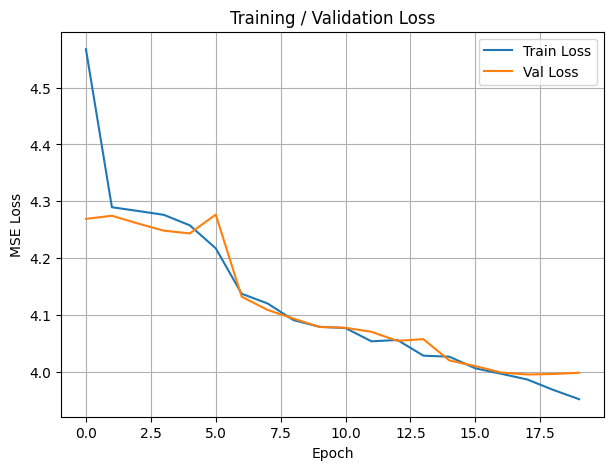

In [10]:
# ====================================================
# 9) LOSS CURVES
# ====================================================

plt.figure(figsize=(7,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training / Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [11]:
# ====================================================
# 10) SAMPLE PREDICTIONS ON VALIDATION SET
#     To validate numerical behavior
# ====================================================

model.eval()
val_iter = iter(val_loader)
x_val_batch, y_val_batch = next(val_iter)
x_val_batch = x_val_batch.to(CFG.device)
y_val_batch = y_val_batch.to(CFG.device)

with torch.no_grad():
    y_pred_batch = model(x_val_batch)

# Convert to CPU numpy for inspection
y_true = y_val_batch.cpu().numpy()
y_pred = y_pred_batch.cpu().numpy()

# Show first few samples (first few frequency points only to keep table small)
n_show = min(3, y_true.shape[0])
freqs_to_show = 10  # first 10 frequency points

for i in range(n_show):
    print(f"\n==== Validation sample {i} ====")
    df_compare = pd.DataFrame({
        "S11_true": y_true[i, :freqs_to_show],
        "S11_pred": y_pred[i, :freqs_to_show],
    })
    display(df_compare)



==== Validation sample 0 ====


,S11_true,S11_pred
0,-0.159020,-0.114533
1,-0.090877,-0.124310
2,-0.186961,-0.242613
3,-0.203826,-0.180514
4,-0.080729,-0.141566
5,-0.225587,-0.214261
6,-0.361638,-0.295446
7,-0.099747,-0.259889
8,-0.028543,-0.345937
9,-0.022090,-0.355956



==== Validation sample 1 ====


,S11_true,S11_pred
0,-0.016816,-0.103597
1,-0.037588,-0.115372
2,-0.082412,-0.219856
3,-0.070767,-0.164932
4,-0.058072,-0.130690
5,-0.084073,-0.192571
6,-0.037144,-0.270789
7,-0.064779,-0.230747
8,-0.036229,-0.322377
9,-0.079648,-0.320119



==== Validation sample 2 ====


,S11_true,S11_pred
0,-0.084909,-0.087148
1,-0.128895,-0.096562
2,-0.186169,-0.174064
3,-12.736387,-0.132583
4,-0.035205,-0.113961
5,-0.018848,-0.155438
6,-0.014233,-0.214526
7,-0.014358,-0.180641
8,-0.017283,-0.252406
9,-0.032451,-0.261359


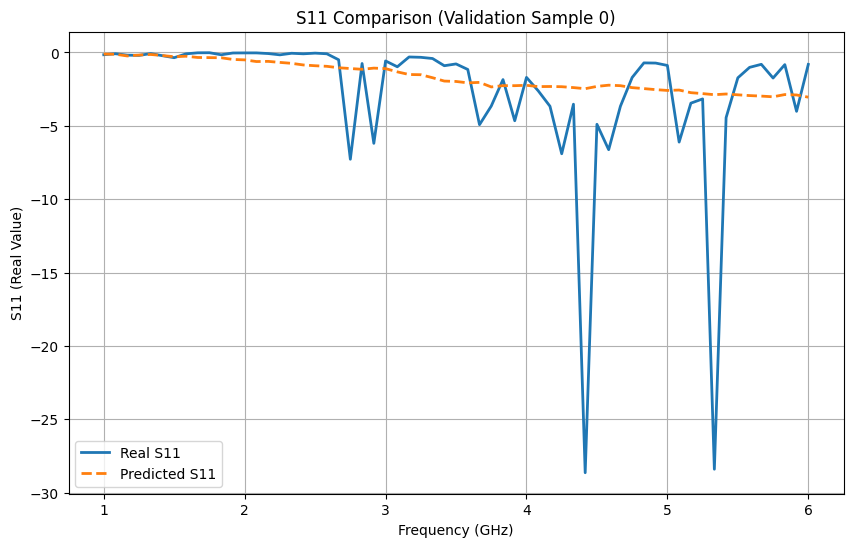

In [12]:
# ====================================================
# 10-B) PLOT S11 vs FREQUENCY FOR PREDICTED & REAL
# ====================================================

# Frequency axis: 1 GHz to 6 GHz over 61 points
freqs = np.linspace(1.0, 6.0, CFG.out_dim)

# Choose one validation example to plot
idx_plot = 0
true_vals = y_true[idx_plot]      # shape (61,)
pred_vals = y_pred[idx_plot]      # shape (61,)

plt.figure(figsize=(10,6))

plt.plot(freqs, true_vals, label="Real S11", linewidth=2)
plt.plot(freqs, pred_vals, label="Predicted S11", linestyle="--", linewidth=2)

plt.title(f"S11 Comparison (Validation Sample {idx_plot})")
plt.xlabel("Frequency (GHz)")
plt.ylabel("S11 (Real Value)")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
# ====================================================
# 11) INFERENCE: NEW GEOMETRY -> PREDICT S11 (REAL VALUES)
# ====================================================

def predict_s11_for_geometry(model, geom_bits_flat, cfg: types.SimpleNamespace):
    """
    geom_bits_flat: 1D array-like of length cfg.in_dim (100 bits 0/1)
    returns: np.array of shape (out_dim,) with predicted real S11 values
    """
    model.eval()
    geom_bits_flat = np.array(geom_bits_flat, dtype=np.float32)

    if geom_bits_flat.shape[0] != cfg.in_dim:
        raise ValueError(f"Expected geometry length {cfg.in_dim}, got {geom_bits_flat.shape[0]}")

    # reshape to (1,1,H,W)
    x = geom_bits_flat.reshape(cfg.grid_h, cfg.grid_w)
    x = np.expand_dims(x, axis=(0,1))   # (1,1,H,W)
    x_tensor = torch.from_numpy(x).float().to(cfg.device)

    with torch.no_grad():
        y_pred = model(x_tensor)        # (1,out_dim)

    return y_pred.cpu().numpy().reshape(-1)


# ---- Example usage #1: from an existing validation sample ----
example_x, _ = val_dataset[0]
example_geom_flat = example_x[0].numpy().reshape(-1)  # (100,)
print("Example geometry bits (first 20):", example_geom_flat[:20])

pred_s11 = predict_s11_for_geometry(model, example_geom_flat, CFG)
print("\nPredicted S11 (first 10 values):")
print(pred_s11[:10])

# ---- Example usage #2: from a manually defined geometry ----
# Replace this with your own 0/1 geometry of length 100:
manual_geom_bits = np.random.randint(0, 2, size=(CFG.in_dim,))
pred_s11_manual = predict_s11_for_geometry(model, manual_geom_bits, CFG)
print("\nManual geometry prediction (first 10 values):")
print(pred_s11_manual[:10])


Example geometry bits (first 20): [0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0.]

Predicted S11 (first 10 values):
[-0.01755576 -0.0228516  -0.12148565 -0.14153738 -0.10309315 -0.09534502
 -0.13981186 -0.11940953 -0.15041873 -0.181813  ]

Manual geometry prediction (first 10 values):
[-0.00466909 -0.01359902 -0.10808674 -0.12536651 -0.08631837 -0.08250588
 -0.12834053 -0.10842833 -0.13294947 -0.16240883]


In [ ]:
# ====================================================
# 12) OPTIONAL: SIMPLE TEXT INPUT INTERFACE (MANUAL)
# ====================================================
# You can run this cell and paste 100 comma-separated 0/1 values
# into the input prompt in Colab to get predictions.

def ask_and_predict(model, cfg):
    print(f"Please enter {cfg.in_dim} comma-separated bits (0 or 1).")
    s = input().strip()
    bits_str = s.split(",")
    if len(bits_str) != cfg.in_dim:
        print(f"Error: you entered {len(bits_str)} values, expected {cfg.in_dim}.")
        return

    geom = np.array([float(b) for b in bits_str], dtype=np.float32)
    y_pred = predict_s11_for_geometry(model, geom, cfg)
    print("\nPredicted S11 values (all 61 points):")
    print(y_pred)

# Uncomment to use:
# ask_and_predict(model, CFG)
